# 1. Data Loading
---
This notebook is intended to be run both locally and on kaggle. Therefore, it needs accomodates the different data sources when loading the csvs. Before handling the data, imports will all be coalesced into a specified subsection.



## 1.1 Imports

In [4]:
"""Student health risk prediction notebook."""
import os
import pandas as pd

# 1.2 Data loading

In [5]:
local_path = os.getcwd()
print(local_path)

/Users/davidlangat/Documents/Github/Kaggle/playground_series/predictining_student_health_risk


In [6]:
def load_data():
    """
    try to load the data from the local directory, if not found, load it from the Kaggle dataset.
    Output the three dataframes: train, test, and submission.
    """

    try:
        # check if the data files are in kaggle direcotry
        # /kaggle/input/competitions/playground-series-s6e7
        print("Trying to load data from kaggle input directory...")
        train = pd.read_csv(
            "/kaggle/input/competitions/playground-series-s6e7/train.csv"
        )
        test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
        submission = pd.read_csv(
            "/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv"
        )
        print("Data loaded successfully from kaggle input directory.")
    except FileNotFoundError:
        print(
            "Data files not found in kaggle input directory.\n"
            "Trying to load data from local directory..."
        )
        # Load data from local directory
        data_dir = os.getcwd() + "/data/"
        train = pd.read_csv(data_dir + "train.csv")
        test = pd.read_csv(data_dir + "test.csv")
        submission = pd.read_csv(data_dir + "sample_submission.csv")
        print("Data loaded successfully from local directory.")

    return train, test, submission

In [7]:
train_df, test_df, submission_df = load_data()

Trying to load data from kaggle input directory...
Data files not found in kaggle input directory.
Trying to load data from local directory...
Data loaded successfully from local directory.


# 2. Data preprocessing
---
Having organised the data into dataframes that can be preprocessed, the necessary quality checks can be done. In this section, we will explore the data for missing values, extreme values and mislabelled data types. 

## 2.1 Check for missing values/null values

In [8]:
def check_missing_values(df):
    """
    Check for missing values in the dataframe and print the count of missing values for each column.
    """
    temp_df = df.copy()
    # check if the dataframe is empty
    if temp_df.empty:
        print("The dataframe is empty. No missing values to check.")
        return
    # check that the dataframe has missing values
    if temp_df.isnull().sum().sum() == 0:
        print("The dataframe has no missing values.")
        return
    # Iterate through each column and check the number of missing values
    for column in temp_df.columns:
        missing_count = temp_df[column].isnull().sum()
        if missing_count > 0:
            # print column name
            # number of missing values againts total number of rows in the column
            total_rows = temp_df.shape[0]
            print(
                f"{column:<25}"
                f"Missing Values: {missing_count:<10}"
                f"Total Rows: {total_rows:<10}"
                f"Percentage Missing: {missing_count / total_rows * 100:.2f}%"
            )

In [9]:
check_missing_values(train_df)


sleep_duration           Missing Values: 75999     Total Rows: 690088    Percentage Missing: 11.01%
heart_rate               Missing Values: 7833      Total Rows: 690088    Percentage Missing: 1.14%
bmi                      Missing Values: 13898     Total Rows: 690088    Percentage Missing: 2.01%
calorie_expenditure      Missing Values: 52853     Total Rows: 690088    Percentage Missing: 7.66%
step_count               Missing Values: 13916     Total Rows: 690088    Percentage Missing: 2.02%
exercise_duration        Missing Values: 6901      Total Rows: 690088    Percentage Missing: 1.00%
water_intake             Missing Values: 43477     Total Rows: 690088    Percentage Missing: 6.30%
diet_type                Missing Values: 6901      Total Rows: 690088    Percentage Missing: 1.00%
stress_level             Missing Values: 82811     Total Rows: 690088    Percentage Missing: 12.00%
sleep_quality            Missing Values: 58331     Total Rows: 690088    Percentage Missing: 8.45%
physical

In [10]:
check_missing_values(test_df)

sleep_duration           Missing Values: 32571     Total Rows: 295753    Percentage Missing: 11.01%
heart_rate               Missing Values: 3357      Total Rows: 295753    Percentage Missing: 1.14%
bmi                      Missing Values: 5956      Total Rows: 295753    Percentage Missing: 2.01%
calorie_expenditure      Missing Values: 22652     Total Rows: 295753    Percentage Missing: 7.66%
step_count               Missing Values: 5964      Total Rows: 295753    Percentage Missing: 2.02%
exercise_duration        Missing Values: 2958      Total Rows: 295753    Percentage Missing: 1.00%
water_intake             Missing Values: 18633     Total Rows: 295753    Percentage Missing: 6.30%
diet_type                Missing Values: 2958      Total Rows: 295753    Percentage Missing: 1.00%
stress_level             Missing Values: 35490     Total Rows: 295753    Percentage Missing: 12.00%
sleep_quality            Missing Values: 24999     Total Rows: 295753    Percentage Missing: 8.45%
physical

### 2.1.1 Remove missing values

In [11]:
def remove_missing_values(df):
    """
    Removes missing values from dataframe by dropping rows with missing values.

    Input-
    df: pandas dataframe

    Output-
    df: pandas dataframe with missing values removed
    """
    temp1_df = df.copy()
    # drop rows with missing values
    temp1_df.dropna(inplace=True)
    # check if thre are any missing values left
    if temp1_df.isnull().sum().sum() == 0:
        print("All missing values removed successfully.")
    check_missing_values(temp1_df)
    return temp1_df


In [12]:
cleaned_train_df = remove_missing_values(train_df)

All missing values removed successfully.
The dataframe has no missing values.


In [13]:
cleaned_test_df = remove_missing_values(test_df)

All missing values removed successfully.
The dataframe has no missing values.


## 2.2 Class imbalance check

In [ ]:
def check_class_imbalance(df):
    """
    Check for class imbalance.
    Plots distribution of target variables.
    target column is assumed to always be health_condition as from competition details.

    Input-
    df: pandas dataframe

    Output-
    None

    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # check if the dataframe is empty
    if df.empty:
        print("The dataframe is empty. No class imbalance to check.")
        return

    # check if the target column exists
    if "health_condition" not in df.columns:
        print("The target column 'health_condition' does not exist in the dataframe.")
        return

    # check if the target column has more than one class
    if df["health_condition"].nunique() <= 1:
        print(
            "The target column 'health_condition' has only one class. No class imbalance to check."
        )
        return

    # Plot grid of multiple different plots to visualize class imbalance
    plt.figure(figsize=(15, 10))
    # Add title to the grid of plots
    plt.suptitle("Health Condition Imbalance Visualization", fontsize=16)

    # Plot horizontal bar chart of health condition with counts of samples
    plt.subplot(2, 2, 1)
    ax = sns.countplot(
        data=df,
        y="health_condition",
        order=df["health_condition"].value_counts().index,
        hue="health_condition",
        palette=sns.color_palette("Set2", df["health_condition"].nunique()),
    )
    # add value counts to the bars
    for container in ax.containers:
        ax.bar_label(
            container,
            label_type="center",
        )

    # Plot pie chart of target variable with percentage of samples in each class
    plt.subplot(2, 2, 2)
    df["health_condition"].value_counts().plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set2", df["health_condition"].nunique()),
    )
    plt.title("Pie Chart of Health Condition")
    # add legend to the pie chart and place it outside the pie chart
    plt.legend(
        labels=df["health_condition"].value_counts().index,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=10,
    )

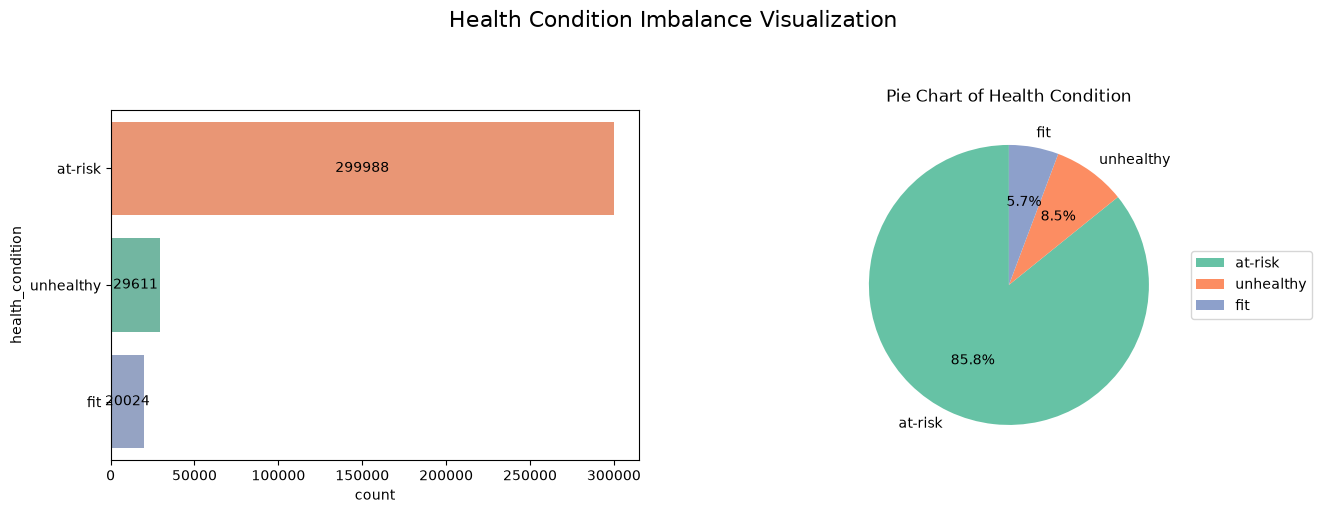

In [38]:
check_class_imbalance(cleaned_train_df)